In [1]:
# %pip targets THIS notebook's kernel. "!pip" often installs into a different Python than the one running the notebook → ModuleNotFoundError.
%pip install torch torchvision transformers huggingface_hub datasets pillow matplotlib numpy

import sys
print("Kernel Python:", sys.executable)

Note: you may need to restart the kernel to use updated packages.
Kernel Python: c:\Users\sable\.pyenv\pyenv-win\versions\3.12.4\python.exe



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: c:\Users\sable\.pyenv\pyenv-win\versions\3.12.4\python.exe -m pip install --upgrade pip


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

c:\Users\sable\.pyenv\pyenv-win\versions\3.12.4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
import json
from pathlib import Path

from huggingface_hub import hf_hub_download
from transformers import SegformerConfig, SegformerForSemanticSegmentation, SegformerImageProcessor

device = "cpu"
model_id = "EPFL-ECEO/segformer-b5-finetuned-coralscapes-1024-1024"

# Hub config is invalid: id2label uses int values (0..39). huggingface_hub expects
# dict[str, str] (human-readable names). Fix before building SegformerConfig.
cfg_path = Path(hf_hub_download(repo_id=model_id, filename="config.json"))
cfg_dict = json.loads(cfg_path.read_text(encoding="utf-8"))
num_labels = int(cfg_dict.get("num_labels", 40))
cfg_dict["id2label"] = {str(i): f"LABEL_{i}" for i in range(num_labels)}
cfg_dict["label2id"] = {f"LABEL_{i}": i for i in range(num_labels)}

config = SegformerConfig.from_dict(cfg_dict)

processor = SegformerImageProcessor.from_pretrained(model_id)
model = SegformerForSemanticSegmentation.from_pretrained(model_id, config=config)

model.to(device)
model.eval()

Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 2989.47it/s]


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)

In [25]:
# Classes stored in the model (from config)
cfg = model.config
print("num_labels:", cfg.num_labels)
print("\nid2label (class index → name):")
for k in sorted(cfg.id2label.keys(), key=lambda x: int(str(x))):
    print(f"  {k}: {cfg.id2label[k]}")
print("\nlabel2id (name → index):")
for name, idx in sorted(cfg.label2id.items(), key=lambda kv: kv[1]):
    print(f"  {idx}: {name}")

num_labels: 40

id2label (class index → name):
  0: LABEL_0
  1: LABEL_1
  2: LABEL_2
  3: LABEL_3
  4: LABEL_4
  5: LABEL_5
  6: LABEL_6
  7: LABEL_7
  8: LABEL_8
  9: LABEL_9
  10: LABEL_10
  11: LABEL_11
  12: LABEL_12
  13: LABEL_13
  14: LABEL_14
  15: LABEL_15
  16: LABEL_16
  17: LABEL_17
  18: LABEL_18
  19: LABEL_19
  20: LABEL_20
  21: LABEL_21
  22: LABEL_22
  23: LABEL_23
  24: LABEL_24
  25: LABEL_25
  26: LABEL_26
  27: LABEL_27
  28: LABEL_28
  29: LABEL_29
  30: LABEL_30
  31: LABEL_31
  32: LABEL_32
  33: LABEL_33
  34: LABEL_34
  35: LABEL_35
  36: LABEL_36
  37: LABEL_37
  38: LABEL_38
  39: LABEL_39

label2id (name → index):
  0: LABEL_0
  1: LABEL_1
  2: LABEL_2
  3: LABEL_3
  4: LABEL_4
  5: LABEL_5
  6: LABEL_6
  7: LABEL_7
  8: LABEL_8
  9: LABEL_9
  10: LABEL_10
  11: LABEL_11
  12: LABEL_12
  13: LABEL_13
  14: LABEL_14
  15: LABEL_15
  16: LABEL_16
  17: LABEL_17
  18: LABEL_18
  19: LABEL_19
  20: LABEL_20
  21: LABEL_21
  22: LABEL_22
  23: LABEL_23
  24: L

In [27]:
from huggingface_hub import list_repo_files

files = list_repo_files("EPFL-ECEO/segformer-b5-finetuned-coralscapes-1024-1024")
print(files)

['.gitattributes', 'README.md', 'config.json', 'model.safetensors', 'preprocessor_config.json']


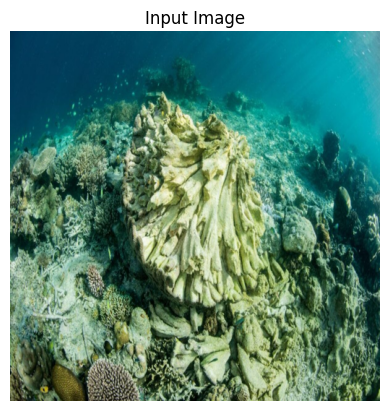

In [16]:
image_path = r"C:\Users\sable\OneDrive\Desktop\coral\coral.jpg"

image = Image.open(image_path).convert("RGB")

# optional resize (recommended for CPU)
image = image.resize((512, 512))

plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

In [28]:
inputs = processor(image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

mask = processor.post_process_semantic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]]
)[0].numpy()

In [30]:
def create_color_map(mask):
    num_classes = mask.max() + 1

    # random colors for each class
    colors = np.random.randint(0, 255, (num_classes, 3), dtype=np.uint8)

    h, w = mask.shape
    color_img = np.zeros((h, w, 3), dtype=np.uint8)

    for c in range(num_classes):
        color_img[mask == c] = colors[c]

    return color_img

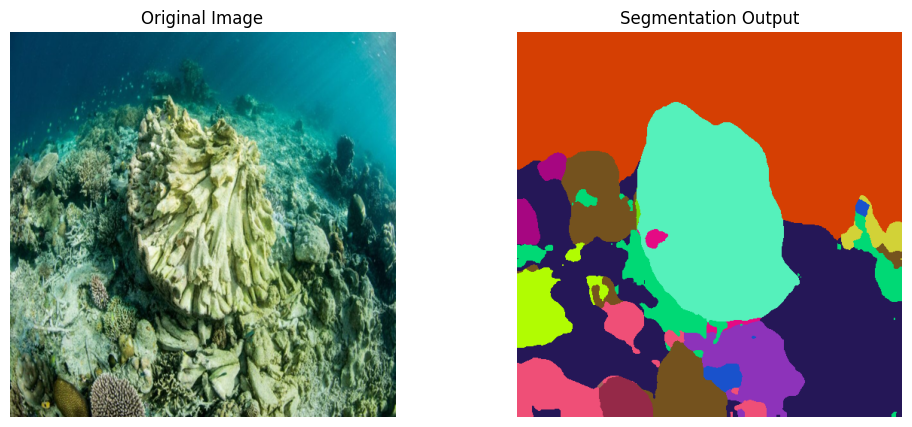

In [31]:
color_mask = create_color_map(mask)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(color_mask)
plt.title("Segmentation Output")
plt.axis("off")

plt.show()

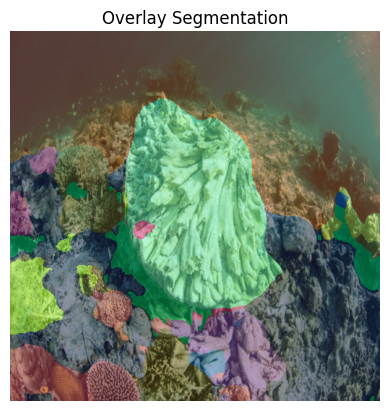

In [32]:
overlay = np.array(image).astype(np.float32)

color_mask = color_mask.astype(np.float32)

result = overlay * 0.6 + color_mask * 0.4
result = result.astype(np.uint8)

plt.imshow(result)
plt.title("Overlay Segmentation")
plt.axis("off")
plt.show()

In [ ]:
%pip install datasets

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor


c:\Users\sable\.pyenv\pyenv-win\versions\3.12.4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from huggingface_hub import scan_cache_dir

cache = scan_cache_dir()

print(cache)

HFCacheInfo(size_on_disk=1988977455, repos=frozenset({CachedRepoInfo(repo_id='google/flan-t5-small', repo_type='model', repo_path=WindowsPath('C:/Users/sable/.cache/huggingface/hub/models--google--flan-t5-small'), size_on_disk=311089056, nb_files=7, revisions=frozenset({CachedRevisionInfo(commit_hash='0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab', snapshot_path=WindowsPath('C:/Users/sable/.cache/huggingface/hub/models--google--flan-t5-small/snapshots/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab'), size_on_disk=311089056, files=frozenset({CachedFileInfo(file_name='tokenizer_config.json', file_path=WindowsPath('C:/Users/sable/.cache/huggingface/hub/models--google--flan-t5-small/snapshots/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/tokenizer_config.json'), blob_path=WindowsPath('C:/Users/sable/.cache/huggingface/hub/models--google--flan-t5-small/snapshots/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/tokenizer_config.json'), size_on_disk=2539, blob_last_accessed=1775133294.14461, blob_last_modified=17751

In [8]:
import json
from pathlib import Path
from huggingface_hub import hf_hub_download
from transformers import SegformerConfig, SegformerForSemanticSegmentation, SegformerImageProcessor

device = "cpu"
model_id = "EPFL-ECEO/segformer-b5-finetuned-coralscapes-1024-1024"

cfg_path = Path(hf_hub_download(repo_id=model_id, filename="config.json"))
cfg_dict = json.loads(cfg_path.read_text(encoding="utf-8"))

num_labels = int(cfg_dict.get("num_labels", 40))

# ✅ FIX: values MUST be strings
cfg_dict["id2label"] = {i: f"LABEL_{i}" for i in range(num_labels)}
cfg_dict["label2id"] = {f"LABEL_{i}": i for i in range(num_labels)}

config = SegformerConfig.from_dict(cfg_dict)

processor = SegformerImageProcessor.from_pretrained(model_id)
model = SegformerForSemanticSegmentation.from_pretrained(
    model_id,
    config=config,
    ignore_mismatched_sizes=True  # helpful safety flag
)

model.to(device)
model.eval()

Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 4507.88it/s]


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)

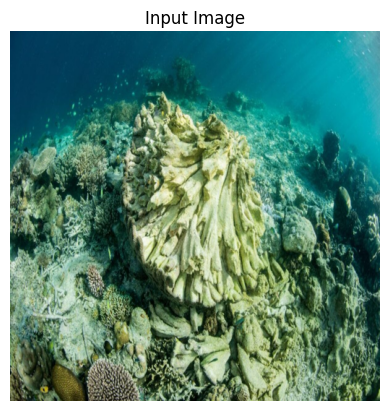

In [10]:
image_path = r"C:\Users\sable\OneDrive\Desktop\coral\coral.jpg"

image = Image.open(image_path).convert("RGB")
image = image.resize((512, 512))

plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

In [11]:
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

mask = processor.post_process_semantic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]]
)[0].cpu().numpy()

In [12]:
id2label = {
    0: "human", 1: "seagrass", 2: "trash", 3: "other coral dead",
    4: "other coral bleached", 5: "sand", 6: "other coral alive",
    7: "human", 8: "transect tools", 9: "fish", 10: "algae covered substrate",
    11: "other animal", 12: "unknown hard substrate", 13: "background",
    14: "dark", 15: "transect line", 16: "massive/meandering bleached",
    17: "massive/meandering alive", 18: "rubble", 19: "branching bleached",
    20: "branching dead", 21: "millepora", 22: "branching alive",
    23: "massive/meandering dead", 24: "clam", 25: "acropora alive",
    26: "sea cucumber", 27: "turbinaria", 28: "table acropora alive",
    29: "sponge", 30: "anemone", 31: "pocillopora alive",
    32: "table acropora dead", 33: "meandering bleached",
    34: "stylophora alive", 35: "sea urchin",
    36: "meandering alive", 37: "meandering dead",
    38: "crown of thorn", 39: "dead clam"
}
label_colors = {
    "human": [255, 0, 0],
    "background": [29, 162, 216],
    "fish": [255, 255, 0],
    "sand": [194, 178, 128],
    "rubble": [161, 153, 128],
    "unknown hard substrate": [125, 125, 125],
    "algae covered substrate": [125, 163, 125],
    "dark": [31, 31, 31],
    "branching bleached": [252, 231, 240],
    "branching dead": [123, 50, 86],
    "branching alive": [226, 91, 157],
    "stylophora alive": [255, 111, 194],
    "pocillopora alive": [255, 146, 150],
    "acropora alive": [236, 128, 255],
    "table acropora alive": [189, 119, 255],
    "table acropora dead": [85, 53, 116],
    "millepora": [244, 150, 115],
    "turbinaria": [228, 255, 119],
    "other coral bleached": [250, 224, 225],
    "other coral dead": [114, 60, 61],
    "other coral alive": [224, 118, 119],
    "massive/meandering alive": [236, 150, 21],
    "massive/meandering dead": [134, 86, 18],
    "massive/meandering bleached": [255, 248, 228],
    "meandering alive": [230, 193, 0],
    "meandering dead": [119, 100, 14],
    "meandering bleached": [251, 243, 216],
    "transect line": [0, 255, 0],
    "transect tools": [8, 205, 12],
    "sea urchin": [0, 142, 255],
    "sea cucumber": [0, 231, 255],
    "anemone": [0, 255, 189],
    "sponge": [240, 80, 80],
    "clam": [189, 255, 234],
    "other animal": [0, 255, 255],
    "trash": [255, 0, 134],
    "seagrass": [125, 222, 125],
    "crown of thorn": [179, 245, 234],
    "dead clam": [89, 155, 134]
}

id2color = {
    i: label_colors[id2label[i]]
    for i in id2label
}
def colorize(mask):
    h, w = mask.shape
    color_img = np.zeros((h, w, 3), dtype=np.uint8)

    for cls_id, color in id2color.items():
        color_img[mask == cls_id] = color

    return color_img

In [13]:
import matplotlib.patches as mpatches

def create_legend(mask):
    unique = np.unique(mask)

    patches = []
    for cls in unique:
        name = id2label.get(cls, f"Unknown {cls}")
        color = np.array(id2color[cls]) / 255.0

        patches.append(
            mpatches.Patch(color=color, label=f"{cls}: {name}")
        )

    return patches

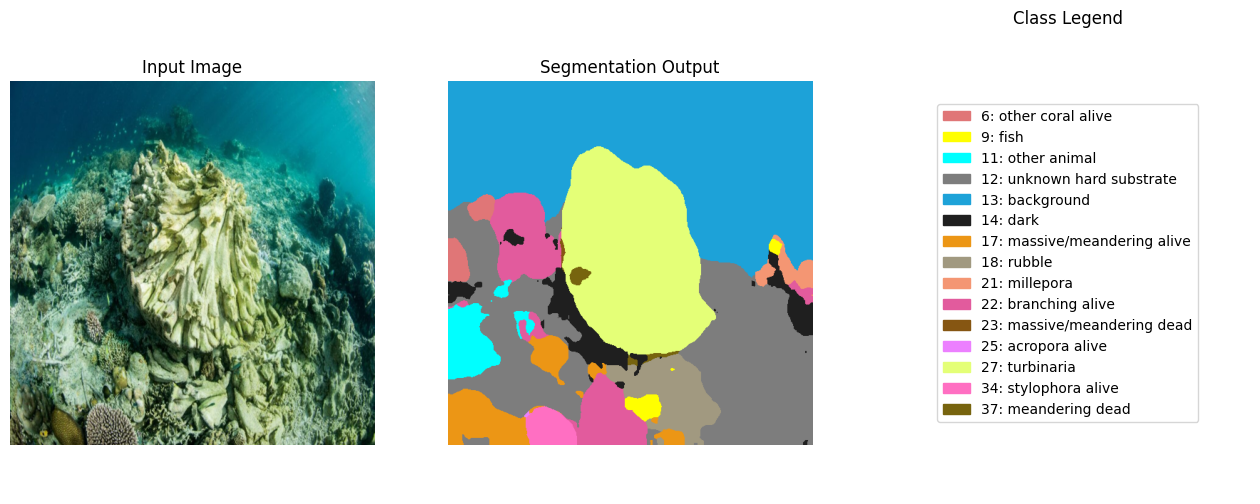

In [14]:
color_mask = colorize(mask)

plt.figure(figsize=(16,6))

# original image
plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

# segmentation
plt.subplot(1,3,2)
plt.imshow(color_mask)
plt.title("Segmentation Output")
plt.axis("off")

# legend
plt.subplot(1,3,3)
plt.axis("off")

patches = create_legend(mask)
plt.legend(handles=patches, loc="center")

plt.title("Class Legend")

plt.show()